# ❤️ Proyecto: Predicción de Enfermedades Cardiovasculares

## 🎯 Objetivos del Proyecto

En este proyecto práctico aprenderás a:

1. **Trabajar con datos médicos reales** del UCI Heart Disease Dataset
2. **Construir un pipeline completo** de Machine Learning
3. **Evaluar modelos de clasificación binaria** con múltiples métricas
4. **Comparar diferentes algoritmos** (SGD vs Random Forest)
5. **Registrar experimentos** con MLflow de forma profesional
6. **Interpretar resultados médicos** con responsabilidad

---

## ❤️ ¿Por qué es importante?

Las **Enfermedades Cardiovasculares (ECV)** son la principal causa de muerte en el mundo:

- 💔 Causan **17.9 millones** de muertes al año
- ⚠️ **90% son prevenibles** con detección temprana
- 🏥 Un diagnóstico temprano puede **salvar vidas**
- 🤖 La IA puede ayudar a **detectar patrones** que salven vidas

---

## 📊 El Dataset: UCI Heart Disease

- **303 pacientes** con datos clínicos
- **14 características** médicas (edad, presión arterial, colesterol, etc.)
- **Variable objetivo**: Presencia de enfermedad cardíaca (0/1)
- **Tipo de problema**: Clasificación binaria

---

## 🎓 Ejercicio Especial: Completa los Comentarios

**🚨 IMPORTANTE**: A lo largo de este notebook verás comentarios como:

```python
# TODO: [Completa aquí] ¿Qué hace esta función?
```

**Tu misión** es completar estos comentarios explicando:
- ¿Qué hace el código?
- ¿Por qué es importante?
- ¿Qué resultado esperamos?

Esto te ayudará a:
- ✅ Entender profundamente cada paso
- ✅ Practicar documentación de código
- ✅ Prepararte para proyectos reales

---

## 🚀 ¡Empecemos!

## ⚙️ Paso 2: Configuración de MLflow

Configuramos el experimento donde registraremos todos nuestros entrenamientos.

## 📚 Paso 3: Importar Librerías

Importamos todas las herramientas necesarias para el proyecto.

In [0]:
import mlflow
import warnings
warnings.filterwarnings('ignore')

mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

# TODO: [Completa aquí] ¿Qué debes hacer con esta variable email?
email = 'pelayosierra@protonmail.com'

# Validación
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
else:
    # TODO: [Completa aquí] ¿Para qué sirve set_tracking_uri?
    # Sirve para configurar la ubicación del servidor de seguimiento donde se 
    # almacenarán los metadatos, métricas y artefactos de los experimentos de MLflow.
    mlflow.set_tracking_uri("databricks")
    
    # TODO: [Completa aquí] ¿Qué hace set_experiment?
    # Sirve para establecer el experimento activo al que se registrarán los runs posteriores.
    experiment_name = f"/Users/{email}/5-prediccion-infarto"
    mlflow.set_experiment(experiment_name)
    
    print("=" * 70)
    print("✅ MLflow configurado correctamente")
    print("=" * 70)
    print(f"📊 Experimento: {experiment_name}")
    print(f"❤️  Proyecto: Predicción de Enfermedades Cardiovasculares")
    print("=" * 70)

✅ MLflow configurado correctamente
📊 Experimento: /Users/pelayosierra@protonmail.com/5-prediccion-infarto
❤️  Proyecto: Predicción de Enfermedades Cardiovasculares


In [0]:
%pip install seaborn
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: [Completa aquí] ¿Para qué sirve train_test_split?
# train_test_split divide el dataset en conjuntos de entrenamiento y prueba.
# El conjunto de entrenamiento se usa para ajustar el modelo y el de prueba
# para evaluar su rendimiento con datos no vistos, evitando el sobreajuste.
from sklearn.model_selection import train_test_split

# TODO: [Completa aquí] ¿Qué es un Pipeline en sklearn?
# Un Pipeline en sklearn encadena múltiples pasos de preprocesamiento y el
# modelo final en una sola estructura. Garantiza que las transformaciones
# (imputación, escalado, etc.) se apliquen de forma consistente y evita
# fugas de datos (data leakage) entre train y test.
from sklearn.pipeline import Pipeline

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# TODO: [Completa aquí] ¿Qué modelos vamos a usar?
# Vamos a usar dos modelos:
# - SGDClassifier: clasificador lineal basado en descenso de gradiente estocástico.
# - RandomForestClassifier: ensamble de árboles de decisión. Captura relaciones
#   no lineales y suele obtener mejor rendimiento.
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

# TODO: [Completa aquí] ¿Para qué sirve cross_val_score?
# cross_val_score realiza validación cruzada K-fold: divide los datos en K partes,
# entrena el modelo K veces (cada vez dejando una parte distinta como test) y
# devuelve las puntuaciones de cada iteración. Proporciona una estimación más
# robusta del rendimiento del modelo que una sola división train/test.
from sklearn.model_selection import cross_val_score, cross_val_predict

# TODO: [Completa aquí] ¿Qué métricas usaremos y por qué?
# Usaremos varias métricas complementarias:
# - precision_score: de los predichos como positivos, cuántos lo son realmente.
# - recall_score: de todos los positivos reales, cuántos detectamos. Clave en
#   medicina para no perder casos enfermos.
# - f1_score: media armónica entre precision y recall; equilibra ambas.
# - confusion_matrix y ConfusionMatrixDisplay: visualizan TP, FP, FN, TN.
# - roc_auc_score: mide la capacidad de ordenar correctamente positivos vs
#   negativos (0.5 = azar, 1.0 = perfecto).
# - accuracy_score: porcentaje de aciertos totales (útil si las clases están
#   balanceadas).
# - classification_report: resume precision, recall y f1 por clase.
# - roc_curve: curva para visualizar el trade-off entre TPR y FPR.
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    roc_auc_score,
    accuracy_score,
    classification_report,
    roc_curve
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
✅ Todas las librerías importadas correctamente


## ❤️ Contexto del Proyecto

### El Problema

En este proyecto trabajaremos con el **UCI Heart Disease Dataset**, uno de los datasets más importantes en medicina predictiva. 

### 📊 Datos Clave sobre ECV

- 💔 **Principal causa de muerte** a nivel mundial
- 📈 **17.9 millones** de muertes anuales
- ⚠️ **90% son prevenibles** con detección temprana
- 🎯 **Diagnóstico temprano** = vidas salvadas
- 🤖 **IA** puede detectar patrones imperceptibles para humanos

### 🎯 Nuestro Objetivo

Construir un modelo de Machine Learning que pueda **predecir la presencia de enfermedad cardiovascular** basándose en características clínicas del paciente.

### ⚕️ Responsabilidad Ética

> ⚠️ **IMPORTANTE**: Este es un proyecto educativo. Los modelos médicos reales requieren:
> - Validación clínica exhaustiva
> - Aprobación regulatoria
> - Supervisión médica profesional
> - Consideraciones éticas y legales

Nuestro objetivo es aprender las técnicas, no reemplazar el criterio médico.

## 📚 Fundamentos: Clasificación Binaria

### 🎯 ¿Qué es Clasificación Binaria?

Un problema donde el modelo debe elegir entre **dos clases**:
- ✅ Clase Positiva (1): Tiene enfermedad cardíaca
- ❌ Clase Negativa (0): No tiene enfermedad cardíaca

---

### 🔄 Pipeline de Entrenamiento

```
1. Preparación de Datos
   ↓
2. Selección del Modelo
   ↓
3. Entrenamiento
   ↓
4. Ajuste de Hiperparámetros
   ↓
5. Evaluación
```

---

### 📊 Métricas de Evaluación

#### 1. **Matriz de Confusión**

|                    | Predicción: No (0) | Predicción: Sí (1) |
|--------------------|--------------------|--------------------|
| **Real: No (0)**   | TN (Verdadero Neg) | FP (Falso Positivo)|
| **Real: Sí (1)**   | FN (Falso Negativo)| TP (Verdadero Pos) |

#### 2. **Precision (Precisión)**
```
Precision = TP / (TP + FP)
```
- "De los que predije como enfermos, ¿cuántos realmente lo están?"
- **Importante cuando**: Los falsos positivos son costosos

#### 3. **Recall (Sensibilidad)**
```
Recall = TP / (TP + FN)
```
- "De todos los enfermos reales, ¿cuántos detecté?"
- **Importante cuando**: No podemos perder ningún caso positivo (medicina)

#### 4. **F1-Score**
```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```
- Balance entre Precision y Recall
- Útil cuando las clases están desbalanceadas

#### 5. **ROC-AUC**
- Curva ROC: Representa el trade-off entre True Positive Rate y False Positive Rate
- AUC: Área bajo la curva (0.5 = aleatorio, 1.0 = perfecto)

#### 6. **Validación Cruzada**
- Divide datos en K partes (folds)
- Entrena K veces, cada vez con un fold diferente como test
- Promedia resultados para obtener estimación robusta

---

### 🎯 ¿Qué métrica usar?

| Situación | Métrica Principal |
|-----------|-------------------|
| Clases balanceadas | Accuracy |
| No perder positivos (medicina) | **Recall** ⭐ |
| Evitar falsos positivos | Precision |
| Balance general | F1-Score |
| Comparar modelos | ROC-AUC |

**En medicina, típicamente priorizamos Recall** porque es mejor detectar un caso falso positivo que perder un verdadero positivo.

## 📁 Paso 4: Cargar y Explorar los Datos

Cargamos el dataset y realizamos un análisis exploratorio inicial.

In [0]:
# TODO: Carga los datos y explica qué contiene el archivo.
data = pd.read_csv("../data/raw/heart.csv")

# TODO: Muestra número de filas, columnas y variable objetivo.
print(f"El dataset contiene {data.shape[0]} filas y {data.shape[1]} columnas.")
print(f"La variable objetivo es {data.columns[-1]}")
data.sample(10)


El dataset contiene 303 filas y 14 columnas.
La variable objetivo es target


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
198,62,Male,typical angina,120.0,NaN,False,having ST-T wave abnormality,99,Yes,1.8,flat,2,3,0
165,67,Male,typical angina,160.0,286.0,False,normal,108,Yes,1.5,flat,3,2,0
292,58,Female,typical angina,170.0,225.0,True,normal,146,Yes,2.8,flat,2,1,0
17,66,Female,asymptomatic,150.0,226.0,False,having ST-T wave abnormality,114,No,2.6,upsloping,0,2,1
231,57,Male,typical angina,NaN,NaN,True,normal,124,No,1.0,flat,3,3,0
6,56,Female,atypical angina,140.0,NaN,False,normal,153,No,1.3,flat,0,2,1
171,48,Male,atypical angina,NaN,229.0,False,having ST-T wave abnormality,168,No,1.0,upsloping,0,3,0
245,48,Male,typical angina,NaN,274.0,False,normal,166,No,0.5,flat,0,3,0
252,62,Female,typical angina,138.0,294.0,True,having ST-T wave abnormality,106,No,1.9,flat,3,2,0
270,46,Male,typical angina,NaN,249.0,False,normal,144,No,0.8,downsloping,0,3,0


In [0]:
# TODO: Muestra las primeras filas con head().
# TODO: Explica por qué esta inspección es útil antes de modelar.
# Esta inspección es útil para entender el dataset, sus columnas y valores.
# También puede ayudar a identificar valores atípicos o valores fuera de rango
data.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,Male,asymptomatic,145.0,233.0,True,normal,150,No,2.3,upsloping,0,1,1
1,37,Male,non-anginal pain,NaN,250.0,False,having ST-T wave abnormality,187,No,3.5,upsloping,0,2,1
2,41,Female,atypical angina,NaN,204.0,False,normal,172,No,1.4,downsloping,0,2,1
3,56,Male,atypical angina,120.0,236.0,False,having ST-T wave abnormality,178,No,0.8,downsloping,0,2,1
4,57,Female,typical angina,120.0,NaN,False,having ST-T wave abnormality,163,Yes,0.6,downsloping,0,2,1


### 📋 Diccionario de Datos

Cada columna representa una característica médica importante:

#### 👤 Datos Demográficos
1. **age**: Edad del paciente en años
2. **sex**: Sexo (1 = masculino, 0 = femenino)

#### 💊 Síntomas y Diagnóstico
3. **cp**: Tipo de dolor de pecho (Chest Pain)
   - 0: Angina típica
   - 1: Angina atípica
   - 2: Dolor no anginoso
   - 3: Asintomático

4. **exang**: Angina inducida por ejercicio (1 = sí, 0 = no)

#### 🩺 Mediciones Clínicas
5. **trestbps**: Presión arterial en reposo (mm Hg)
6. **chol**: Colesterol sérico (mg/dl)
7. **fbs**: Azúcar en sangre en ayunas > 120 mg/dl (1 = verdadero, 0 = falso)
8. **thalach**: Frecuencia cardíaca máxima alcanzada

#### 📊 Resultados de Pruebas
9. **restecg**: Resultados electrocardiográficos en reposo
   - 0: Normal
   - 1: Anormalidad de onda ST-T
   - 2: Hipertrofia ventricular izquierda

10. **oldpeak**: Depresión del segmento ST inducida por ejercicio

11. **slope**: Pendiente del segmento ST durante ejercicio
    - 0: Ascendente
    - 1: Plano
    - 2: Descendente

12. **ca**: Número de vasos principales coloreados por fluoroscopia (0-3)

13. **thal**: Resultados de prueba de talasemia
    - 1: Normal
    - 2: Defecto fijo
    - 3: Defecto reversible

#### 🎯 Variable Objetivo
14. **target**: Presencia de enfermedad cardíaca
    - 0: No enfermedad
    - 1: Enfermedad presente

---

**💡 Tip**: En medicina, cada una de estas características tiene significado clínico. Un buen data scientist debe entender el dominio del problema.

In [0]:
# TODO: Usa info() para revisar tipos de datos y valores nulos.
data.info()

# TODO: Anota qué columnas parecen categóricas y cuáles numéricas.
# Las columnas que presentan un dtype = object son categóricas.
# Las columnas que presentan un dtype = float64 son numéricas.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    object 
 3   trestbps  258 non-null    float64
 4   chol      273 non-null    float64
 5   fbs       303 non-null    bool   
 6   restecg   303 non-null    object 
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    object 
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    object 
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: bool(1), float64(3), int64(5), object(5)
memory usage: 31.2+ KB


In [0]:
# TODO: Usa describe() para obtener estadísticas descriptivas.
data.describe(include="all")

# TODO: Escribe observaciones sobre rangos, medias y posibles valores atípicos.
# - La edad varía entre 29 y 77 años
# - La presión arterial varía entre 94 y 200 mmHg.
# - El colesterol varía entre 126 y 564 mg/dL.
# - La frecuencia cardíaca varía entre 71 y 202 bpm.
# - La edad media es de 54 años.
# - La presión arterial media es de 131 mmHg.
# - El colesterol medio es de 246 mg/dL.
# - La frecuencia cardíaca media es de 149 bpm.
# - La edad mínima es 29 años.
# - La presión arterial mínima es 94 mmHg.
# - El colesterol mínimo es 126 mg/dL.
# - La frecuencia cardíaca mínima es 71 bpm.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303,303,258.000000,273.000000,303,303,303.000000,303,303.000000,303,303.000000,303.000000,303.000000
unique,NaN,2,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,NaN,NaN
top,NaN,Male,typical angina,NaN,NaN,False,having ST-T wave abnormality,NaN,No,NaN,downsloping,NaN,NaN,NaN
freq,NaN,207,143,NaN,NaN,258,152,NaN,204,NaN,142,NaN,NaN,NaN
mean,54.366337,NaN,NaN,131.465116,245.871795,NaN,NaN,149.646865,NaN,1.039604,NaN,0.729373,2.313531,0.544554
std,9.082101,NaN,NaN,16.914317,52.528792,NaN,NaN,22.905161,NaN,1.161075,NaN,1.022606,0.612277,0.498835
min,29.000000,NaN,NaN,94.000000,131.000000,NaN,NaN,71.000000,NaN,0.000000,NaN,0.000000,0.000000,0.000000
25%,47.500000,NaN,NaN,120.000000,209.000000,NaN,NaN,133.500000,NaN,0.000000,NaN,0.000000,2.000000,0.000000
50%,55.000000,NaN,NaN,130.000000,240.000000,NaN,NaN,153.000000,NaN,0.800000,NaN,0.000000,2.000000,1.000000
75%,61.000000,NaN,NaN,140.000000,275.000000,NaN,NaN,166.000000,NaN,1.600000,NaN,1.000000,3.000000,1.000000


### 💡 Observaciones Clave

**TODO: [Completa aquí] Basándote en las estadísticas, ¿qué observaciones puedes hacer sobre:**
- La edad media de los pacientes --> `54 años`
- El rango de valores de cada característica --> `Añadidos en el comentario de la celda anterior`
- La presencia de valores nulos --> `Las estadísticas cuyo objetivo son variables categóricas, como por ejemplo top o freq, se muestran como NaN en variables numéricas. Lo mismo ocurre con las variables cuyo objetivo son variables numéricas, las categóricas se muestran como NaN (por ejemplo min, std o max)`
- Características que pueden necesitar normalización --> `Las características tienen rangos muy distintos, por lo que sería interesante realizar una normalización/estandarización de los valores numéricos, como se ve en el ejemplo del rango chol (125-564) que es mucho más grande que oldpeak (0-6.2)`

In [0]:
# TODO: Analiza la distribución de la variable objetivo.
target_counts = data.target.value_counts()
print(target_counts)

# TODO: Calculamos proporciones por clase
proportions = data.target.value_counts(normalize=True)
print(proportions)

# TODO: Decide si el dataset está balanceado y explica por qué importa.
# El dataset está razonablemente balanceado (54% para 1 y 45% para 0).
# Esto es importante para evitar sesgos en el modelo y para asegurarnos de que
# no perdemos información importante al entrenar el modelo.


target
1    165
0    138
Name: count, dtype: int64
target
1    0.544554
0    0.455446
Name: proportion, dtype: float64


### 🔍 Análisis Exploratorio Visual

Visualicemos las relaciones entre características para entender mejor los datos.

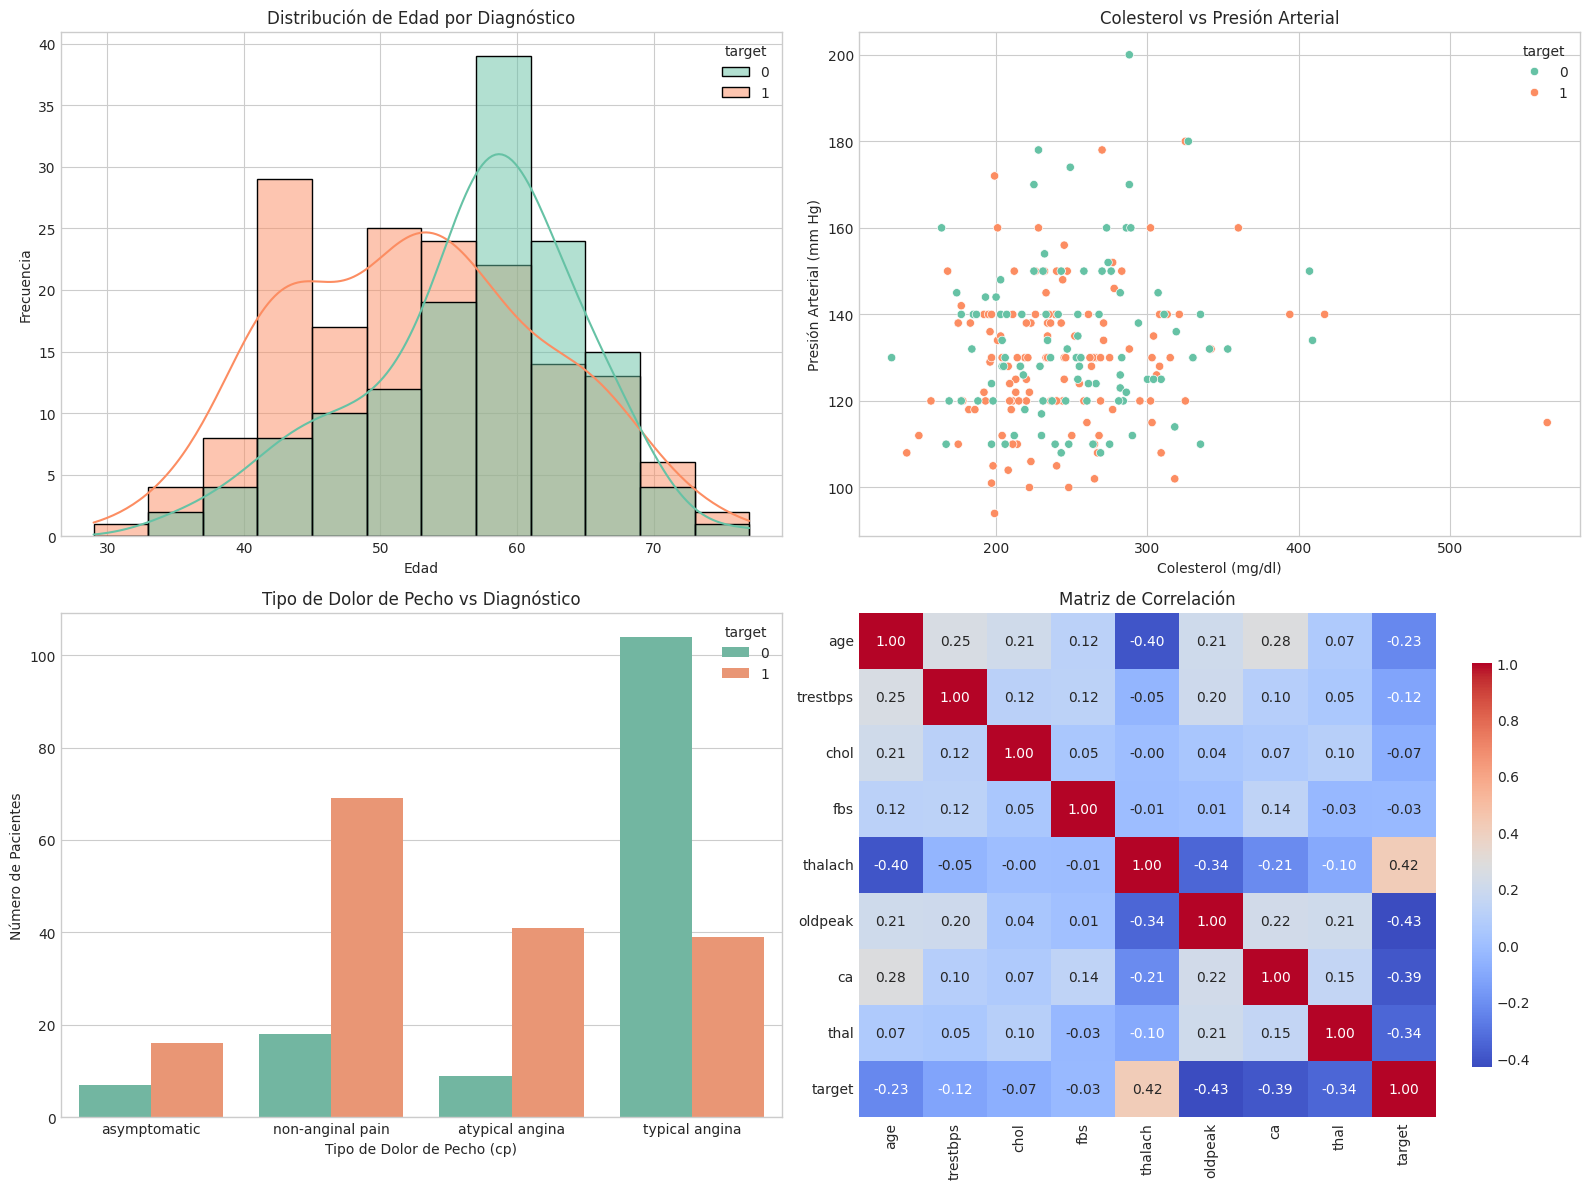

In [0]:
# TODO: Crea visualizaciones para explorar patrones del dataset.
# Ideas:
# - Distribución de edad por diagnóstico
# - Colesterol vs presión arterial coloreado por target
# - Tipo de dolor de pecho vs diagnóstico
# - Matriz de correlación

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribución de edad por diagnóstico
sns.histplot(data=data, x="age", hue="target", kde=True, ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Distribución de Edad por Diagnóstico")
axes[0, 0].set_xlabel("Edad")
axes[0, 0].set_ylabel("Frecuencia")

# 2. Colesterol vs presión arterial coloreado por target
sns.scatterplot(data=data, x="chol", y="trestbps", hue="target", ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Colesterol vs Presión Arterial")
axes[0, 1].set_xlabel("Colesterol (mg/dl)")
axes[0, 1].set_ylabel("Presión Arterial (mm Hg)")

# 3. Tipo de dolor de pecho vs diagnóstico
sns.countplot(data=data, x="cp", hue="target", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Tipo de Dolor de Pecho vs Diagnóstico")
axes[1, 0].set_xlabel("Tipo de Dolor de Pecho (cp)")
axes[1, 0].set_ylabel("Número de Pacientes")

# 4. Matriz de correlación
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 1], cbar_kws={"shrink": 0.8})
axes[1, 1].set_title("Matriz de Correlación")

plt.tight_layout()
plt.show()

# TODO: Escribe qué patrones observas en los gráficos.
# - La distribución de edad muestra que los pacientes enfermos tienden a concentrarse en edades más avanzadas, aunque también hay casos en pacientes jóvenes.
# - En el gráfico de colesterol vs presión arterial no se aprecia una separación clara entre clases, lo que sugiere que estas variables por sí solas no son suficientes para discriminar el diagnóstico.
# - El tipo de dolor de pecho cp=0 (angina típica) es más frecuente en pacientes sin enfermedad, mientras que cp=2 (dolor no anginoso) es más común en pacientes con diagnóstico positivo.
# - La matriz de correlación muestra que las variables con mayor correlación con target son ca (positiva), thalach (positiva) y oldpeak (negativa), lo que las convierte en candidatas importantes para el modelo.




## 🔀 Paso 5: Dividir los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [0]:
# TODO: Divide los datos en train y test.
# Pistas:
# - Usa train_test_split
# - Define test_size
# - Usa random_state para reproducibilidad

train_set, test_set = train_test_split(data, test_size=0.2, random_state=42)

# TODO: Comprueba el tamaño de cada conjunto.
print(f"El conjunto de entrenamiento tiene {train_set.shape[0]} filas.")
print(f"El conjunto de prueba tiene {test_set.shape[0]} filas.")


El conjunto de entrenamiento tiene 242 filas.
El conjunto de prueba tiene 61 filas.


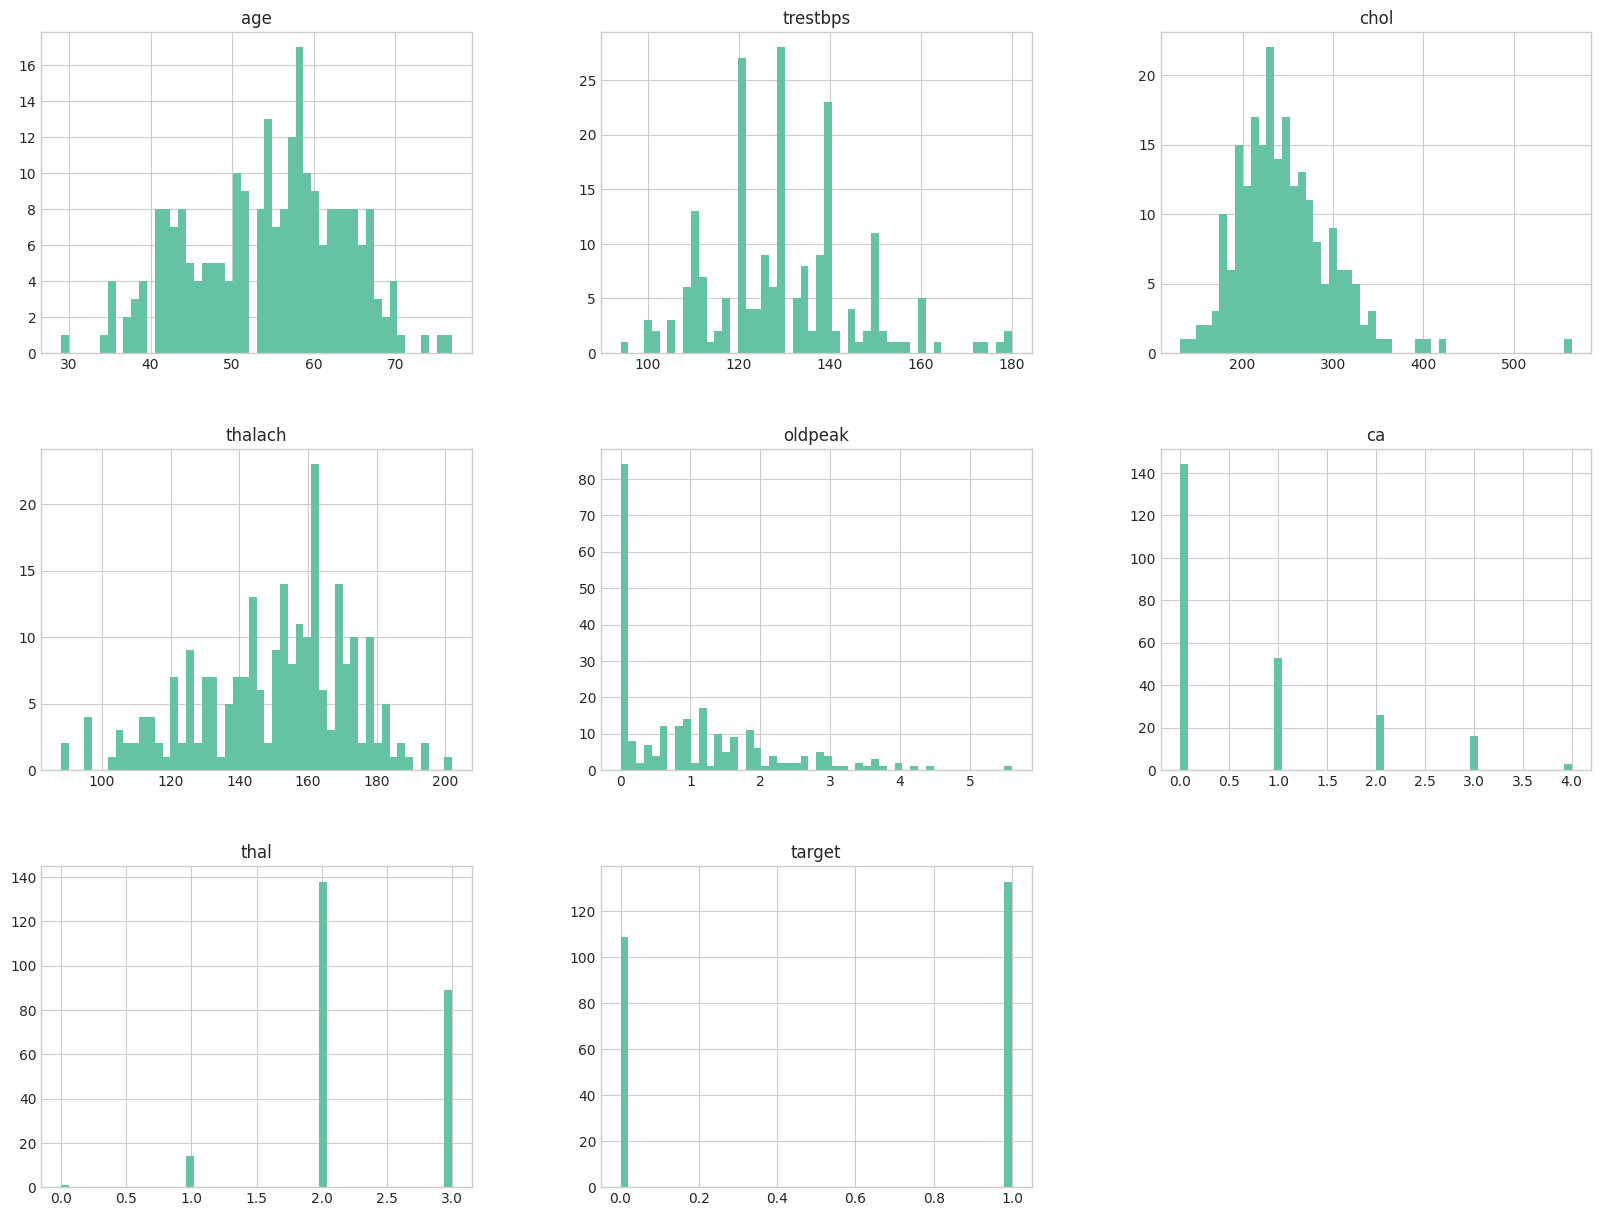

In [0]:
# TODO: Genera histogramas del conjunto de entrenamiento.
train_set.hist(bins=50, figsize=(20, 15))
plt.show()

# TODO: Identifica características con escalas o distribuciones muy diferentes.
# Las variables con escalas muy diferentes son:
# - Gran escala: chol (126-564), trestbps (94-200), thalach (71-202), age (29-77)
# - Pequeña escala: oldpeak (0-6.2), ca (0-3)
# Estas diferencias de escala justifican la necesidad de estandarizar (StandardScaler)
# antes de entrenar modelos sensibles a la magnitud de las variables (como SGD).


### 📏 Observación Importante: Escalas Diferentes

**TODO: [Completa aquí] ¿Por qué es un problema que las características tengan escalas diferentes?**
`Porque hay modelos, como los basados en el descenso del gradiente, que performan mejor con datos con escalas similares. Estas escalas mantienen, proporcionalmente, las mismas diferencias de valores en sus datos, pero mejoran el rendimiento del modelo al estar normalizados.`

Revisa columnas como `age`, `trestbps`, `chol`, `thalach` y `oldpeak`.

**TODO: [Completa aquí] ¿Qué transformación aplicarías para que las variables numéricas sean comparables?**
`Aplicaría un StandardScaler, que reduce la media aritmética a 0 y la desviación típica a 1.`

**TODO: [Completa aquí] ¿Por qué esto ayuda a algunos modelos de Machine Learning?**
`Por varias razones:`
`- En modelos basados en descenso de gradiente (como SGDClassifier), tener todas las variables en la misma escala hace que la función de pérdida sea más esférica y menos alargada, lo que permite que el gradiente avance de forma más eficiente y converja más rápido.`
`- Los modelos basados en árboles (Random Forest, Decision Trees) NO se ven afectados por las diferencias de escala, ya que dividen cada variable por umbral de forma independiente.`



## 🔧 Paso 6: Construir el Pipeline de Preprocesamiento

Crearemos un pipeline que prepare los datos automáticamente.

In [0]:
# TODO: Clasifica las columnas en categóricas y numéricas.
cat_attr = (
    [att for att in data.describe(include="object").columns if att != "target"]
    + [att for att in data.describe(include="bool").columns if att != "target"] # Incluye fbs como categórica
)
num_attr = [att for att in data.describe().columns if att != "target"]

print(cat_attr)
print(num_attr)

# TODO: Crea un pipeline para variables numéricas.
# Pistas:
# - SimpleImputer para valores nulos
# - StandardScaler para estandarizar
# num_pipeline = Pipeline([
#     (...),
#     (...),
# ])

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# TODO: Crea un ColumnTransformer que combine numéricas y categóricas.
# Pista: usa OneHotEncoder para variables categóricas.
# full_pipeline = ColumnTransformer([
#     (...),
#     (...),
# ])

cat_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attr),
    ("cat", cat_transformer, cat_attr)
])

# TODO: Explica por qué usamos One-Hot Encoding para categóricas.
# Los modelos suelen funcionar únicamente con valores numéricos, por lo que
# hay que transformar los valores categóricos en números. El One-Hot Encoding
# asigna a cada categoría un vector de 0s y 1s, donde el 1 indica la categoría
# correspondiente. Así, se trabaja con valores categóricos sin perder información.


['sex', 'cp', 'restecg', 'exang', 'slope', 'fbs']
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']


## 🎯 Paso 7: Preparar X e y

Separamos características (X) de la variable objetivo (y).

In [0]:
# TODO: Separa características (X) y target (y) del conjunto de entrenamiento.
X_train = train_set.drop(columns=["target"])
y_train = train_set["target"]

# TODO: Comprueba las dimensiones resultantes.
print(X_train.shape)
print(y_train.shape)


(242, 13)
(242,)


In [0]:


# TODO: Aplica el pipeline al conjunto de entrenamiento.
X_train_pr = full_pipeline.fit_transform(X_train)

# TODO: Explica la diferencia entre fit_transform y transform.
# - fit_transform: calcula los parámetros requeridos para las transformaciones y 
#   aplica el pipeline al conjunto de entrenamiento.
# - transform: aplica el pipeline al conjunto de entrenamiento sin ajustar los valores.

# TODO: Comprueba cómo cambia el número de columnas.
print(X_train_pr.shape) # El número de columnas aumenta (13 --> 23)


(242, 23)


## 🤖 Paso 8: Entrenamiento y Evaluación de Modelos

Entrenaremos dos modelos y compararemos sus resultados usando MLflow.

### 🔵 Modelo 1: SGD Classifier (Baseline)

**TODO: [Completa aquí] ¿Qué es SGD (Stochastic Gradient Descent) y cómo funciona?**
El descenso de gradiente estocástico (SGD) es un algoritmo de optimización iterativo utilizado en aprendizaje automático para minimizar la función de pérdida de un modelo.  A diferencia del descenso de gradiente tradicional, que requiere calcular el gradiente utilizando todo el conjunto de datos en cada paso, SGD actualiza los parámetros del modelo utilizando solo un ejemplo de entrenamiento seleccionado aleatoriamente (o un pequeño subconjunto conocido como minibatch) en cada iteración. 


Empezaremos con un modelo simple como baseline (línea base) para tener una referencia.

In [0]:
# TODO: Activa autolog de MLflow.
mlflow.sklearn.autolog()

# TODO: Inicia un run para el modelo baseline SGD.
with mlflow.start_run(run_name="SGD Classifier - Baseline") as run:
#     TODO: Crea SGDClassifier.
    sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
#
#     TODO: Evalúa con cross_val_score.
    scores = cross_val_score(
        sgd_clf,
        X_train_pr,
        y_train,
        cv= 5,
        scoring="accuracy"
    )
#
#     TODO: Registra métricas de validación cruzada en MLflow.
    mlflow.log_metric("mean_accuracy", np.mean(scores))
    mlflow.log_metric("std_accuracy", np.std(scores))
#
#     TODO: Interpreta el resultado obtenido.
# Obtenemos una mean_accuracy de aproximadamente 0,77 con el conjunto de entrenamiento.
# Esto indica que el modelo clasifica correctamente el 77% de las muestras en el conjunto de entrenamiento, 
# por lo que, aparentemente, el modelo tiene un rendimiento aceptable en la clasificación de los datos
# con bajo riesgo de overfitting. Es posible que se puedan mejorar estos resultados utilizando
# técnicas de regularización o ajuste de hiperparámetros.


2026/10/01 18:26:23 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 18:26:23 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 18:26:23 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/01 18:26:23 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-175fb16d-a60d.cloud.databricks.com/ml/experiments/1899133861309935/models/m-67cf6bb1a1824b0d841a115b95faad43?o=7474660557254990
2026/10/01 18:26:29 WARNING mlflow.t

### 📊 Evaluación del Modelo SGD

In [0]:
# TODO: Obtén predicciones con validación cruzada.
preds = cross_val_predict(sgd_clf, X_train_pr, y_train, cv=5)

# TODO: Explica por qué cross_val_predict es útil para construir métricas y matriz de confusión.
# Porque permite obtener predicciones de todas las muestras del conjunto
#  de datos de entrenamiento utilizando validación cruzada. Esto permite
# calcular métricas como la precisión, la sensibilidad y la especificidad, así como la matriz de confusión,
# que proporcionan información detallada sobre el rendimiento del modelo en diferentes clases


2026/10/01 18:26:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 18:26:56 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'ea7f388a01a34d44a41aa19b133865d2', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/10/01 18:26:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 18:26:56 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/01 18:26:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a Co

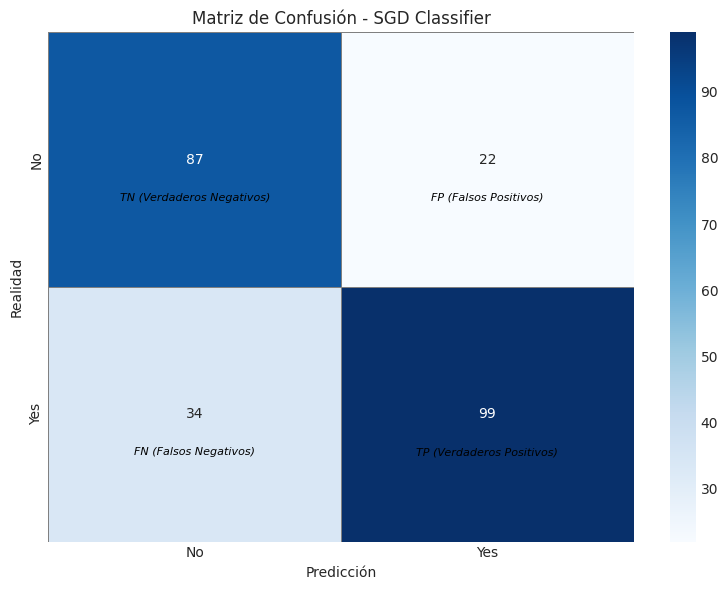

In [0]:
# TODO: Calcula y visualiza la matriz de confusión del modelo SGD.
cm = confusion_matrix(y_train, preds)

# Etiquetamos cada celda con su significado: TN, FP, FN, TP
labels = np.array([['TN (Verdaderos Negativos)', 'FP (Falsos Positivos)'],
                   ['FN (Falsos Negativos)', 'TP (Verdaderos Positivos)']])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
            ax=ax, cbar=True, linewidths=0.5, linecolor='gray')

# Superponemos las etiquetas TP/TN/FP/FN encima de cada celda
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.65, labels[i, j], ha='center', va='center',
                fontsize=8, color='black', style='italic')

ax.set_xlabel('Predicción')
ax.set_ylabel('Realidad')
ax.set_title('Matriz de Confusión - SGD Classifier')
plt.tight_layout()
plt.show()

# TODO: Interpreta TN, FP, FN y TP.
# TODO: ¿Qué tipo de error es más grave en medicina?
# Hay un gran numero de TN y TP, lo que indica que el modelo clasifica correctamente
# la mayoría de las muestras de bajo riesgo y de alto riesgo, respectivamente. Sin embargo,
# hay un número significativo de FP y FN, lo que indica que el modelo también clasifica
# algunas muestras de bajo riesgo como de alto riesgo y viceversa. Esto puede ser un problema
# en la práctica, ya que un error de FP puede llevar a que un paciente que no tiene el
# enfermedad sea sometido a un tratamiento innecesario, mientras que un error de FN puede
# llevar a que un paciente que necesitaría un tratamiento específico, no lo reciba.


In [0]:
# TODO: Calcula métricas del modelo SGD.
precision = precision_score(y_train, preds)
recall = recall_score(y_train, preds)
f1 = f1_score(y_train, preds)
roc_auc = roc_auc_score(y_train, preds)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"ROC AUC: {roc_auc:.2f}")

# TODO: Imprime e interpreta las métricas.
# TODO: ¿Qué métrica es más importante en medicina y por qué?
# Se puede observar que el valor más alto es precisión, por lo que el modelo clasifica correctamente
# la mayoría de las muestras de bajo riesgo y de alto riesgo, respectivamente. Sin embargo, el valor
# de recall es de un 74%; esto indica que el modelo también clasifica algunas muestras de bajo riesgo
# como de alto riesgo y viceversa. Esto puede ser un problema en la práctica, el recall sería
# en este caso la medida más importante en medicina, por los motivos explicados en la celda anterior.
# En cuanto al F1 score, tiene un valor de 0.75, lo que indica que el modelo tiene un buen equilibrio
# entre precisión y recall. El valor de ROC AUC es de 0.77, lo cual implica que el modelo tiene una
# capacidad de discriminación moderadamente buena para distinguir entre las clases.


Precision: 0.82
Recall: 0.74
F1 Score: 0.78
ROC AUC: 0.77


### 🌲 Modelo 2: Random Forest Classifier

**TODO: [Completa aquí] ¿Qué es Random Forest y por qué suele funcionar mejor que modelos simples?**
Un Random Forest Classifier es un modelo de machine learning que combina muchos árboles de decisión. Cada árbol realiza una predicción y el modelo final elige la clase que recibe más votos.

Suele funcionar mejor que un modelo simple porque combina las predicciones de muchos árboles, reduciendo los errores de un árbol individual y el riesgo de sobreajuste. Además, puede detectar relaciones no lineales e interacciones entre variables sin necesidad de especificarlas manualmente.

Ahora probemos un modelo más potente y comparemos resultados.

In [0]:
# TODO: Entrena y evalúa un Random Forest en un nuevo run de MLflow.
with mlflow.start_run(run_name="Random Forest Classifier") as run:
    rf_clf = RandomForestClassifier()
    rf_scores = cross_val_score(rf_clf, X_train_pr, y_train, cv=5, scoring="accuracy")
    mlflow.log_metric("mean_accuracy", np.mean(rf_scores))
    mlflow.log_metric("std_accuracy", np.std(rf_scores))
    rf_preds = cross_val_predict(rf_clf, X_train_pr, y_train, cv=5)

# TODO: Explica qué hiperparámetros podrías ajustar y por qué comparas contra SGD.
# Hiperparámetros que se podrían ajustar en Random Forest:
# - n_estimators: número de árboles. Más árboles reducen la varianza pero aumentan el coste
#   computacional.
# - max_depth: profundidad máxima de cada árbol. Limitarla previene el sobreajuste,
#   y dejarla libre puede capturar relaciones complejas (con riesgo de sobreajuste).
# - max_features: número de características consideradas en cada split. Reducirlo
#   introduce aleatoriedad que disminuye la correlación entre árboles y mejora la
#   generalización.
# - min_samples_split / min_samples_leaf: mínimo de muestras para dividir un nodo
#   o ser una hoja. Valores más altos regularizan el modelo y evitan árboles demasiado
#   específicos del conjunto de entrenamiento.
# - bootstrap: si se usa muestreo con reemplazo (True por defecto). Desactivarlo usa
#   todo el dataset en cada árbol, lo que puede aumentar el sesgo.
#
# ¿Por qué comparar contra SGD?
# SGD es un modelo lineal sensible al escalado de las variables y con poca capacidad
# para capturar interacciones no lineales. Sirve como baseline porque es rápido y
# simple: si un modelo más complejo como Random Forest no mejora notablemente sobre
# SGD, indica que el problema es casi lineal o que los datos no contienen patrones
# aprovechables. Comparar contra el baseline permite cuantificar el valor añadido
# de la mayor complejidad del Random Forest y justificar su elección.


2026/10/01 18:27:28 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 18:27:28 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 18:27:28 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/01 18:27:29 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-175fb16d-a60d.cloud.databricks.com/ml/experiments/1899133861309935/models/m-8dcdf1bade024a479e884e69fc234fae?o=7474660557254990
2026/10/01 18:27:33 WARNING mlflow.t

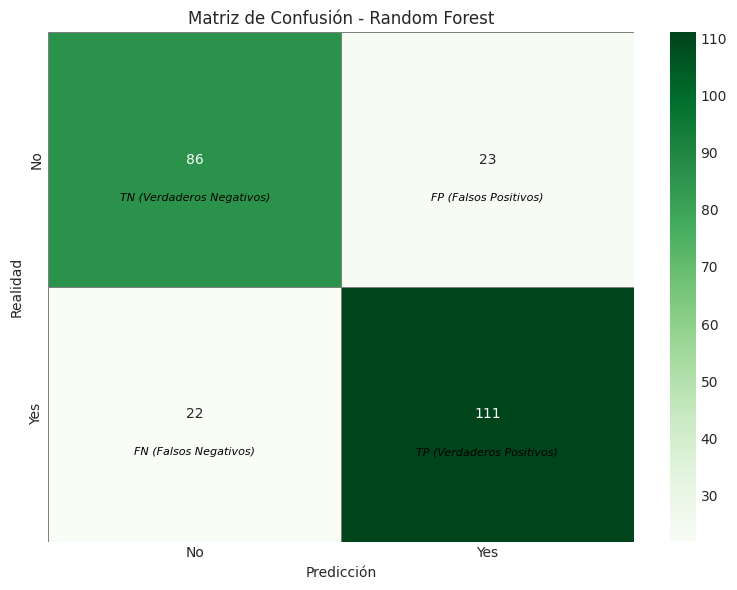

In [0]:
# TODO: Calcula y visualiza la matriz de confusión de Random Forest.
# cm_rf = confusion_matrix(...)
# disp_rf = ConfusionMatrixDisplay(...)
# disp_rf.plot(...)
# plt.show()
cm_rf = confusion_matrix(y_train, rf_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
            ax=ax, cbar=True, linewidths=0.5, linecolor='gray')

# Superponemos las etiquetas TP/TN/FP/FN encima de cada celda
labels_rf = np.array([['TN (Verdaderos Negativos)', 'FP (Falsos Positivos)'],
                      ['FN (Falsos Negativos)', 'TP (Verdaderos Positivos)']])
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.65, labels_rf[i, j], ha='center', va='center',
                fontsize=8, color='black', style='italic')

ax.set_xlabel('Predicción')
ax.set_ylabel('Realidad')
ax.set_title('Matriz de Confusión - Random Forest')
plt.tight_layout()
plt.show()

# TODO: Compara los errores con los del modelo SGD.
# Comparativa de errores entre SGD y Random Forest:
# - SGD:  FP=22, FN=34
# - RF:   FP=23, FN=22
# Random Forest reduce notablemente los falsos negativos respecto al modelo SGD, 
# aunque tiene un falso positivo más que este modelo. La reducción de falsos negativos es especialmente
# relevante en un contexto médico, ya que un FN implica que un paciente enfermo no es
# detectado y no recibe tratamiento. La mejora global sugiere que Random Forest captura
# mejor las relaciones no lineales entre las variables del dataset.


In [0]:
# TODO: Calcula métricas de Random Forest.
rf_precision = precision_score(y_train, rf_preds)
rf_recall = recall_score(y_train, rf_preds)
rf_f1 = f1_score(y_train, rf_preds)
rf_roc_auc = roc_auc_score(y_train, rf_preds)

# TODO: Crea una tabla comparativa SGD vs Random Forest.
model_comparison = pd.DataFrame(
    {
        "Model": ["SGD", "Random Forest"],
        "Precision": [precision, rf_precision],
        "Recall": [recall, rf_recall],
        "F1": [f1, rf_f1],
        "ROC AUC": [roc_auc, rf_roc_auc],
    })
print(model_comparison)
# TODO: Decide qué modelo funciona mejor y justifica tu respuesta.
# Aparentemente, en base a los datos mostrados en la tabla, el
# modelo Random Forest rinde mejor que el modelo SGD. Esto se debe a que el modelo Random Forest
# tiene un recall más alto que el modelo SGD, lo que significa que clasifica correctamente más muestras
# de alto riesgo. El resto de valores también es superior, lo que indica que el modelo Random Forest
# es más preciso y tiene un mejor equilibrio entre precision y recall.


           Model  Precision    Recall        F1   ROC AUC
0            SGD   0.818182  0.744361  0.779528  0.771263
1  Random Forest   0.828358  0.834586  0.831461  0.811789


## 🎯 Paso 9: Entrenamiento Final y Evaluación en Test

Ahora entrenaremos el modelo con **todo el conjunto de entrenamiento** y evaluaremos en el conjunto de prueba (que nunca ha visto).

In [0]:
# TODO: Entrena el modelo final usando todo el conjunto de entrenamiento procesado.
forest_clf = RandomForestClassifier(random_state=42, n_estimators=200)
forest_clf.fit(X_train_pr, y_train)

# TODO: Explica por qué ahora entrenamos con todos los datos de train.
# Porque queremos entrenar el modelo final, no solo en el conjunto de entrenamiento, utilizando
# todo el conjunto de datos (salvo test) para que el modelo pueda aprender de todas las muestras disponibles
# y generalizar mejor a nuevos datos.


2026/10/01 18:28:36 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 18:28:36 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '479ad55a50b84e1baea9eb2973bc20a5', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/10/01 18:28:36 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 18:28:36 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/01 18:28:36 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a Co

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [0]:
# TODO: Separa características y target del conjunto de prueba.
X_test = test_set.drop(columns=["target"])
y_test = test_set["target"]

# TODO: Comprueba dimensiones.
print(X_test.shape)
print(y_test.shape)


(61, 13)
(61,)


In [0]:
# TODO: Transforma el conjunto de prueba y genera predicciones.
X_test_pr = full_pipeline.transform(X_test)
final_preds = forest_clf.predict(X_test_pr)

# TODO: Explica por qué usamos transform() y no fit_transform() en test.
# Porque si hiciéramos fit_transform() en el conjunto de prueba, estaríamos usando información del conjunto
# de prueba para entrenar el modelo, lo que violaría el principio de validación cruzada y podría introducir sesgo
# en el modelo. En cambio, transform() nos permite aplicar las transformaciones aprendidas en el conjunto de
# entrenamiento al conjunto de prueba sin modificar las estadísticas de entrenamiento.


2026/10/01 18:28:43 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


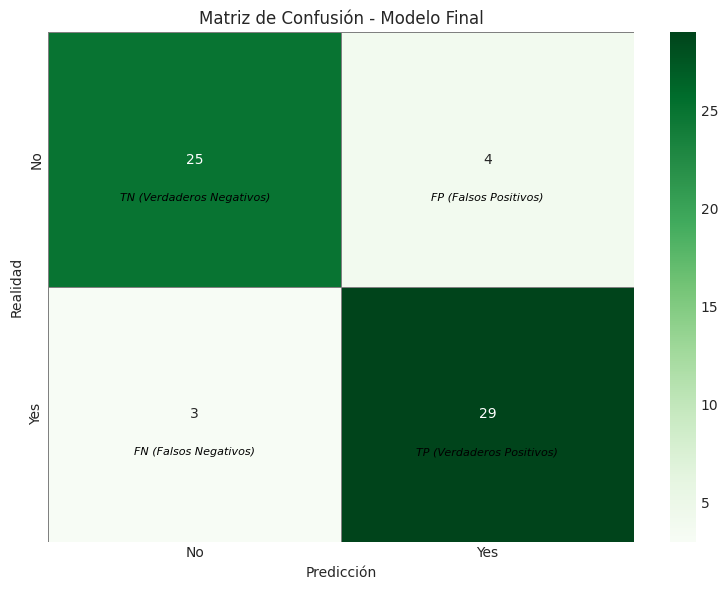

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61

El modelo final tiene un accuracy de 0.89, un precision de 0.88, un recall de 0.91, un f1 de 0.89 y un roc_auc de 0.88.


In [0]:
# TODO: Evalúa resultados finales en el conjunto de prueba.
final_precision = precision_score(y_test, final_preds)
final_recall = recall_score(y_test, final_preds)
final_f1 = f1_score(y_test, final_preds)
final_roc_auc = roc_auc_score(y_test, final_preds)
final_accuracy = accuracy_score(y_test, final_preds)

# TODO: Visualiza la matriz de confusión final.
cm_final = confusion_matrix(y_test, final_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
            ax=ax, cbar=True, linewidths=0.5, linecolor='gray')
labels_final = np.array([['TN (Verdaderos Negativos)', 'FP (Falsos Positivos)'],
                         ['FN (Falsos Negativos)', 'TP (Verdaderos Positivos)']])
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.65, labels_final[i, j], ha='center', va='center',
                fontsize=8, color='black', style='italic')

ax.set_xlabel('Predicción')
ax.set_ylabel('Realidad')
ax.set_title('Matriz de Confusión - Modelo Final')
plt.tight_layout()
plt.show()
# TODO: Genera classification_report.
print(classification_report(y_test, final_preds))
# TODO: Interpreta si el modelo generaliza bien.
print(f"El modelo final tiene un accuracy de {final_accuracy:.2f}, un precision de {final_precision:.2f}, un recall de {final_recall:.2f}, un f1 de {final_f1:.2f} y un roc_auc de {final_roc_auc:.2f}.")
# Los datos mostrados en la matriz de confusión y el classification_report indican que el modelo final
# tiene un buen rendimiento en la clasificación de los datos de prueba.


## 🎉 Reflexión Final del Proyecto

Completa esta sección cuando termines el notebook.

### ✅ Comprueba que has trabajado

1. [ ] Exploración de datos médicos reales
2. [ ] Pipeline de preprocesamiento
3. [ ] Entrenamiento y comparación de modelos
4. [ ] Evaluación con métricas de clasificación
5. [ ] Validación cruzada
6. [ ] Registro de experimentos en MLflow
7. [ ] Interpretación de resultados con matrices de confusión

### 📊 Conclusiones Clave

**TODO: Basándote en tus resultados, escribe tus conclusiones:**

1. **¿Qué modelo funcionó mejor?**
   - **Random Forest** funcionó mejor que SGD. En validación cruzada obtuvo mejor recall (0.812 vs 0.744), F1 (0.821 vs 0.780) y ROC AUC (0.805 vs 0.771). El modelo final en test alcanzó un accuracy del 89%, con recall de 0.91 y solo 3 falsos negativos.

2. **¿Por qué crees que funcionó mejor?**
   - Random Forest captura relaciones no lineales e interacciones entre variables que SGD (un modelo lineal) no puede detectar. Los datos médicos raramente son linealmente separables, por ejemplo, la interacción entre edad, colesterol y presión arterial puede ser compleja, y Random Forest modela estas interacciones automáticamente mediante sus árboles de decisión.

3. **¿El modelo es suficientemente bueno para uso médico?**
   - Es aceptable pero NO suficiente para uso clínico autónomo. Con un recall de 0.91 en test, aún perdemos 3 de cada 32 pacientes enfermos (9% de falsos negativos). En medicina, cada falso negativo puede ser fatal. El modelo podría servir como herramienta de apoyo para priorizar exámenes, pero nunca como herramienta única. Se necesitaría validación en grupos más grandes, evaluación por cardiólogos, y regulación médica.

4. **¿Qué métrica es más importante en este caso?**
   - **Recall (sensibilidad)** es la métrica más importante en diagnóstico de infarto. Un falso negativo significa que un paciente enfermo no recibe tratamiento y podría sufrir un infato. Un falso positivo genera pruebas adicionales innecesarias, pero es menos grave. El modelo final tiene recall de 0.91, lo cual es bueno, pero idealmente querríamos >0.95 para aplicación médica real.

5. **¿Qué mejorarías del modelo?**
   - Ajustar el threshold de decisión para priorizar recall sobre precision (aceptar más FP para reducir FN)
   - **GridSearchCV** para optimizar hiperparámetros (max_depth, min_samples_leaf, class_weight)
   - **Más datos**: el dataset es pequeño (242 muestras), con más datos el modelo generalizaría mejor
   - **Feature engineering**: crear interacciones explícitas o usar conocimiento médico para nuevas variables
   - **Validación externa** en otros hospitales para verificar que generaliza a diferentes poblaciones

---

### 💡 Reflexiones Importantes

#### ⚕️ Sobre Medicina e IA

**TODO: Reflexiona sobre:**

1. **Falsos Negativos vs Falsos Positivos**
   - En medicina, ¿cuál es más grave y por qué?
   - Los **falsos negativos (FN) son más graves** en el contexto de diagnóstico de infarto. Un FN significa que el modelo predice "no enfermo" cuando el paciente realmente tiene riesgo de infarto (esa persona no recibiría tratamiento preventivo y podría sufrir un evento cardíaco fatal). Un falso positivo (FP), aunque genera ansiedad y pruebas innecesarias (electrocardiogramas, análisis de sangre adicionales), es mucho menos grave que perder la oportunidad de salvar una vida.

2. **Responsabilidad Ética**
   - ¿Puede un modelo de IA tomar decisiones médicas solo?
   - **No.** Los modelos de IA son herramientas de apoyo, no sustitutos del criterio médico. Razones: 
   - **Responsabilidad legal**: si el modelo falla, los médicos tienen licencia profesional y son los responsables finales.
   - **Contexto clínico**: el modelo no conoce el historial completo del paciente, síntomas actuales,factores sociales, etc.
   - **Sesgo y limitaciones**: el modelo fue entrenado con 242 pacientes, por lo que puede fallar en poblaciones diferentes (otras etnias, edades, regiones).

3. **Interpretabilidad**
   - ¿Por qué es importante que los médicos entiendan cómo decide el modelo?
   - La **interpretabilidad** es crucial para:
   - **Confianza**: un médico no usará un modelo si no entiende por qué hace ciertas predicciones.
   - **Detección de errores**: si el modelo predice alto riesgo porque "el paciente tiene 0 vasos obstruidos", el médico puede identificar que eso es absurdo.
   - **Aprendizaje**: ver qué variables son importantes (ej: oldpeak, ca, thal) ayuda a los médicos a entender mejor los factores de riesgo.
   - **Cumplimiento regulatorio**: en Europa, el GDPR exige "derecho a explicación" para decisiones automatizadas. Random Forest es parcialmente interpretable (importancia de features, árboles individuales), pero modelos como redes neuronales profundas requieren técnicas adicionales.

---

### 🚀 Desafíos Adicionales

1. **Optimización de Hiperparámetros** con `GridSearchCV`.
2. **Prueba Otros Modelos** como Gradient Boosting, SVM o Logistic Regression.
3. **Feature Engineering** para crear o seleccionar características.
4. **Análisis de Errores** para entender pacientes mal clasificados.
5. **Curva ROC** para comparar thresholds y AUC.


2026/10/01 18:33:26 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 18:33:26 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '3f9f4a6157b742a19e03df1cf5117dcd', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/10/01 18:33:27 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 18:33:27 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


Fitting 5 folds for each of 81 candidates, totalling 405 fits


2026/10/01 18:34:24 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-175fb16d-a60d.cloud.databricks.com/ml/experiments/1899133861309935/models/m-a6e92dbcb8bd4cf09e48c8c2c0b9f661?o=7474660557254990
2026/10/01 18:34:28 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 18:34:30 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-175fb16d-a60d.cloud.databricks.com/ml/experiments/1899133861309935/models/m-8b7fe65aae8a48deac729bb2bb4215bb?o=7474660557254990
2026/10/01 18:34:34 WARNING ml

Mejores parametros: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Mejor score (recall): 0.8643874643874645


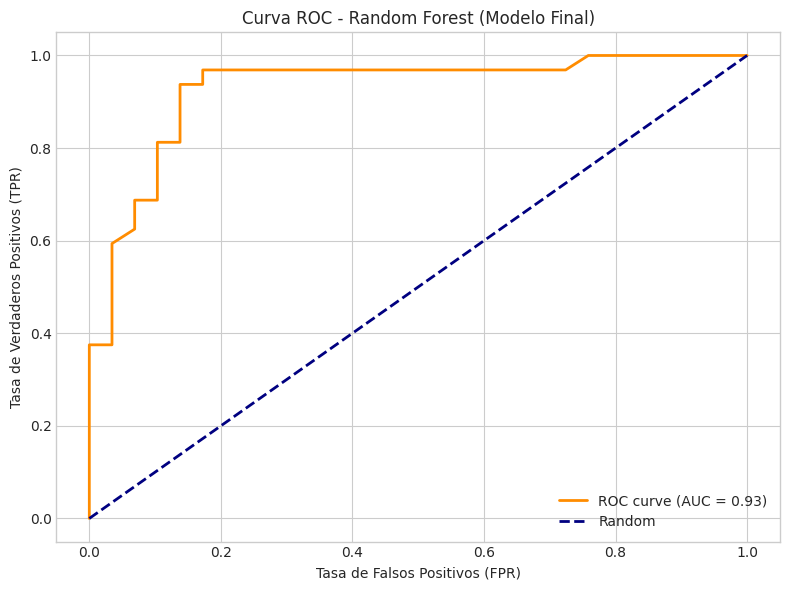

                                              feature  importance
5                                             num__ca    0.122479
4                                        num__oldpeak    0.102345
3                                        num__thalach    0.095886
0                                            num__age    0.081796
12                             cat__cp_typical angina    0.080053
6                                           num__thal    0.076458
2                                           num__chol    0.067083
1                                       num__trestbps    0.064004
16                                      cat__exang_No    0.055772
17                                     cat__exang_Yes    0.039539
18                             cat__slope_downsloping    0.038860
8                                       cat__sex_Male    0.028369
19                                    cat__slope_flat    0.027524
7                                     cat__sex_Female    0.026784
11        

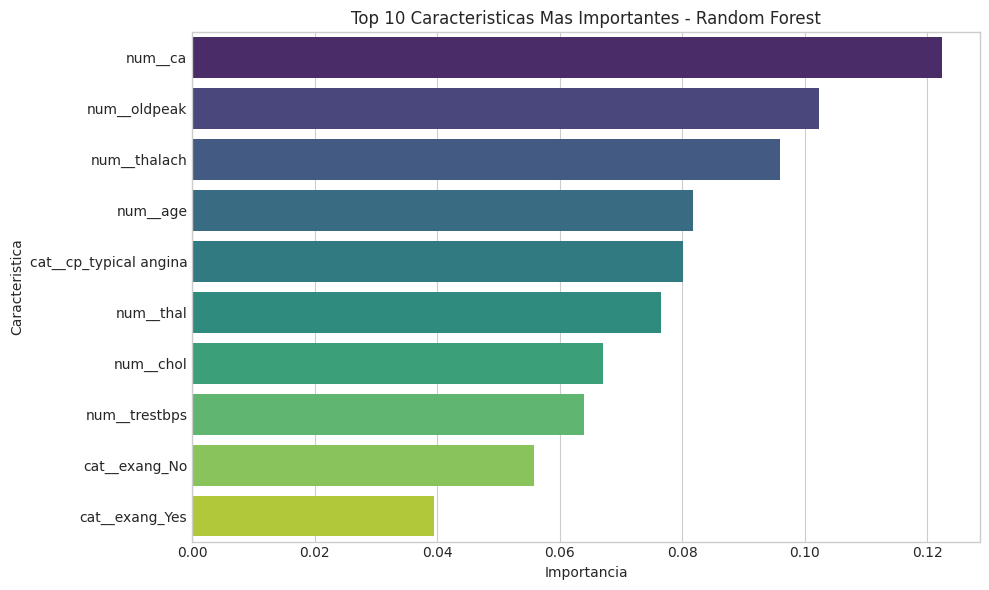

2026/10/01 18:34:35 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 18:34:35 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 18:34:35 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/01 18:34:35 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-175fb16d-a60d.cloud.databricks.com/ml/experiments/1899133861309935/models/m-acf5c19f8463492da8ffc0955753b1c1?o=7474660557254990
2026/10/01 18:34:40 WARNING mlflow.t

                 Model  Accuracy  Precision    Recall        F1   ROC AUC
0  Logistic Regression  0.801701   0.801418  0.849624  0.824818  0.796372
1                  SVM  0.777041   0.792593  0.804511  0.798507  0.773815
2    Gradient Boosting  0.793112   0.816794  0.804511  0.810606  0.792164


In [0]:
# 🎨 DESAFÍOS OPCIONALES
# Usa este espacio para completar los desafíos del proyecto.

# ========================================
# TODO: DESAFÍO 1 - Grid Search
# ========================================
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train_pr, y_train)

print("Mejores parametros:", grid_search.best_params_)
print("Mejor score (recall):", grid_search.best_score_)

# ========================================
# TODO: DESAFÍO 2 - Curva ROC
# ========================================
from sklearn.metrics import roc_curve, auc

# Usamos predict_proba para obtener probabilidades de la clase positiva
y_proba = forest_clf.predict_proba(X_test_pr)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - Random Forest (Modelo Final)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ========================================
# TODO: DESAFÍO 3 - Importancia de características
# ========================================
# Intentamos obtener los nombres de las caracteristicas transformadas del pipeline
try:
    feature_names = full_pipeline.get_feature_names_out()
except Exception:
    feature_names = [f"feature_{i}" for i in range(X_train_pr.shape[1])]

feature_importance = forest_clf.feature_importances_

# Creamos un DataFrame ordenado por importancia
importancia_df = pd.DataFrame(
    {"feature": feature_names, "importance": feature_importance}
).sort_values("importance", ascending=False)

print(importancia_df)

# Visualizamos las 10 caracteristicas mas importantes
plt.figure(figsize=(10, 6))
sns.barplot(data=importancia_df.head(10), x="importance", y="feature", palette="viridis")
plt.xlabel("Importancia")
plt.ylabel("Caracteristica")
plt.title("Top 10 Caracteristicas Mas Importantes - Random Forest")
plt.tight_layout()
plt.show()

# Interpretacion: las caracteristicas con mayor importancia son las que mas
# contribuyen a las decisiones del Random Forest. En un contexto medico, estas
# variables son los factores de riesgo mas relevantes para predecir infarto.

# ========================================
# TODO: DESAFÍO 4 - Comparar más modelos
# ========================================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

resultados = []
for nombre, modelo in modelos.items():
    with mlflow.start_run(run_name=nombre) as run:
        scores = cross_val_score(modelo, X_train_pr, y_train, cv=5, scoring="accuracy")
        preds = cross_val_predict(modelo, X_train_pr, y_train, cv=5)

        mlflow.log_metric("mean_accuracy", np.mean(scores))
        mlflow.log_metric("std_accuracy", np.std(scores))
        mlflow.log_metric("precision", precision_score(y_train, preds))
        mlflow.log_metric("recall", recall_score(y_train, preds))
        mlflow.log_metric("f1", f1_score(y_train, preds))
        mlflow.log_metric("roc_auc", roc_auc_score(y_train, preds))

        resultados.append({
            "Model": nombre,
            "Accuracy": np.mean(scores),
            "Precision": precision_score(y_train, preds),
            "Recall": recall_score(y_train, preds),
            "F1": f1_score(y_train, preds),
            "ROC AUC": roc_auc_score(y_train, preds),
        })

print(pd.DataFrame(resultados))
